# 📊 **02_Data_Understanding**

This notebook aims to understand the structure, quality, and distribution of raw data scraped from the Google Play Store before entering the cleaning and analysis phase.

| # | Segment | Objective |
|---|--------|--------|
| 1 | Import Library | Prepare all required tools |
| 2 | Configuration Setup | Define paths, colors, and visualization preferences |
| 3 | Load Data | Read CSVs per platform and merge them |
| 4 | Data Overview | View the initial data format and sample |
| 5 | Dataset Information | Check column types and number of non-null values ​​|
| 6 | Check Duplicates | Ensure no rows are repeated |
| 7 | Check Missing Values ​​| Identify columns with empty data |
| 8 | Reviews per Platform | Distribution of the number of reviews across platforms |
| 9 | Score Distribution | Distribution of star ratings per platform |
| 10 | Statistical Summary | Numerical and per-platform descriptive statistics |
| 11 | Review Volume Over Time | Monthly review volume trends |
| 12 | Review Length Distribution | Distribution of review text lengths |


## **1. Import Libraries**
Imports all libraries needed throughout this notebook. `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for visualization, and `pathlib` for cross-OS file path management.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import os

## **2. Configuration Setup**
Defines all global constants: data folder paths, platform-specific brand color palettes, and visualization display standards. All platform names are kept in lowercase as a key consistency standard.

In [2]:
# Mengabaikan peringatan (warnings) yang tidak perlu
warnings.filterwarnings("ignore")

# Mengatur standar visualisasi
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10
})

# Dictionary warna brand dan daftar platform (huruf kecil sebagai standar key)
PALETTE = {"grab": "#00B14F", "gojek": "#00AED6", "maxim": "#FF6900", "indrive": "#3B2D8E"}
PLATFORMS = ["grab", "gojek", "maxim", "indrive"]

# Folder path — sesuaikan jika struktur foldermu berbeda
DATA_DIR  = Path("../data/raw/google_play_reviews")  # ← FIX: DATA_DIR didefinisikan di sini
CLEAN_DIR = Path("../data/clean")
FIG_DIR   = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Konfigurasi berhasil dimuat.")
print(f"   DATA_DIR  : {DATA_DIR}")
print(f"   CLEAN_DIR : {CLEAN_DIR}")
print(f"   FIG_DIR   : {FIG_DIR}")

✅ Konfigurasi berhasil dimuat.
   DATA_DIR  : ..\data\raw\google_play_reviews
   CLEAN_DIR : ..\data\clean
   FIG_DIR   : ..\reports\figures


## **3. Load Data**
Automatically reads scraped CSV files for each platform and merges them into a single DataFrame (`df_all`) with the addition of a `platform` column as a label. The `at` and `repliedAt` columns are immediately parsed as datetimes.

In [3]:
dfs = {}
for p in PLATFORMS:
    fp = DATA_DIR / f"{p}_reviews.csv"
    if fp.exists():
        dfs[p] = pd.read_csv(fp, parse_dates=["at", "repliedAt"])
        print(f"✅ {p:10s} | {len(dfs[p]):>6,} rows | {dfs[p].shape[1]} cols")
    else:
        print(f"❌ {p} — file tidak ditemukan: {fp}")

# Gabungkan semua platform menjadi satu DataFrame
df_all = pd.concat(
    [v.assign(platform=k) for k, v in dfs.items()],
    ignore_index=True
)
print(f"\n📦 Combined: {len(df_all):,} rows × {df_all.shape[1]} cols")

✅ grab       | 25,000 rows | 9 cols
✅ gojek      | 25,000 rows | 9 cols
✅ maxim      | 25,000 rows | 9 cols
✅ indrive    | 25,000 rows | 9 cols

📦 Combined: 100,000 rows × 10 cols


## **4. Overview Data**
Menampilkan 5 baris pertama untuk memverifikasi struktur kolom, tipe nilai, dan format data sudah sesuai ekspektasi setelah proses load dan merge.


In [4]:
# Tampilkan 5 baris pertama dari gabungan data
display(df_all.head())
print(f"\nShape: {df_all.shape[0]:,} rows × {df_all.shape[1]} cols")
print(f"Kolom: {df_all.columns.tolist()}")

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,platform
0,835e7763-142a-4e9f-b469-12a40a0e401c,Sarwan safi'i,bagus,5,0,5.407.0,2026-05-27 12:26:00,NaN,NaT,grab
1,f78aa2f2-a017-4ee6-812e-8aec61e118a4,Vane Sya,perbaikan tuh aplikasi lu udah ongkir mahal vo...,2,0,5.411.0,2026-05-27 12:03:43,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️ Apab...,2026-05-28 08:06:04,grab
2,f760f0c6-160e-45d7-b53f-b28a15db51d6,nje Zen,ga berguna untuk mesenin org tua yg lagi dilua...,1,0,NaN,2026-05-27 11:47:58,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,2026-05-27 12:55:11,grab
3,a55a721e-242e-453f-9cde-e7e25cd07698,Selalu Rantau,matap,5,0,5.411.0,2026-05-27 11:34:27,NaN,NaT,grab
4,f7f4886b-cc2b-4561-8fe3-095936460039,Ari Gnk,Sangat OK,5,0,5.411.0,2026-05-27 11:32:32,NaN,NaT,grab



Shape: 100,000 rows × 10 cols
Kolom: ['reviewId', 'userName', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'platform']


> Data was successfully loaded with a structure of **100,000 rows × 10 columns** from 4 platforms, where the `replyContent`, `repliedAt`, and `reviewCreatedVersion` columns were already seen to have **NaN** values ​​since the first row, indicating that not all reviews received developer replies or application version information, which will be further quantified in the *Check Missing Values* segment.

## **5. Dataset Information**
Check the data type of each column and the number of non-null values. Columns with a significantly lower number of non-null values ​​indicate missing values, critical information before cleaning.

In [5]:
# Cek tipe data dan jumlah non-null setiap kolom
print("Informasi Dataset:")
df_all.info()

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   reviewId              100000 non-null  object        
 1   userName              99999 non-null   object        
 2   content               100000 non-null  object        
 3   score                 100000 non-null  int64         
 4   thumbsUpCount         100000 non-null  int64         
 5   reviewCreatedVersion  82459 non-null   object        
 6   at                    100000 non-null  datetime64[ns]
 7   replyContent          28930 non-null   object        
 8   repliedAt             28930 non-null   datetime64[ns]
 9   platform              100000 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(6)
memory usage: 7.6+ MB


> Of the 10 columns, only **3 columns have missing values**: `userName` (1 row. Likely anonymous account), `reviewCreatedVersion` (17,541 missing. Many users don't update the app before the review), and `replyContent` and `repliedAt` which both have only **28,930 out of 100,000 rows**, meaning only **~29% of reviews received a developer reply**. The data types are read correctly — `score` and `thumbsUpCount` as `int64`, `at` and `repliedAt` as `datetime64`, and the total memory usage is only **7.6 MB** which is light to process.

## **6. Check Duplicates**
Checks for identical rows (all columns are the same). Duplicates can occur due to overlapping scraping or files being loaded more than once. If there are any, details will be displayed.

In [6]:
# Cek jumlah total baris yang duplikat (semua kolom identik)
total_duplikat = df_all.duplicated().sum()
print(f"Total data duplikat: {total_duplikat} baris")

# Tampilkan detail jika ada duplikat
if total_duplikat > 0:
    print("\nDetail Data Duplikat:")
    display(df_all[df_all.duplicated(keep=False)])
else:
    print("✅ Tidak ada duplikat — data bersih di level baris.")

Total data duplikat: 0 baris
✅ Tidak ada duplikat — data bersih di level baris.


> **Expected output:** 0 duplicates. This means each review is unique at the row level.

## **7. Check Missing Values**
Counts the number and percentage of missing values ​​(NaN) in each column, sorted from most to most. Horizontal bar visualization makes it easy to compare between columns.

                      missing  pct_missing
replyContent            71070        71.07
repliedAt               71070        71.07
reviewCreatedVersion    17541        17.54
reviewId                    0         0.00
userName                    1         0.00
content                     0         0.00
thumbsUpCount               0         0.00
score                       0         0.00
at                          0         0.00
platform                    0         0.00


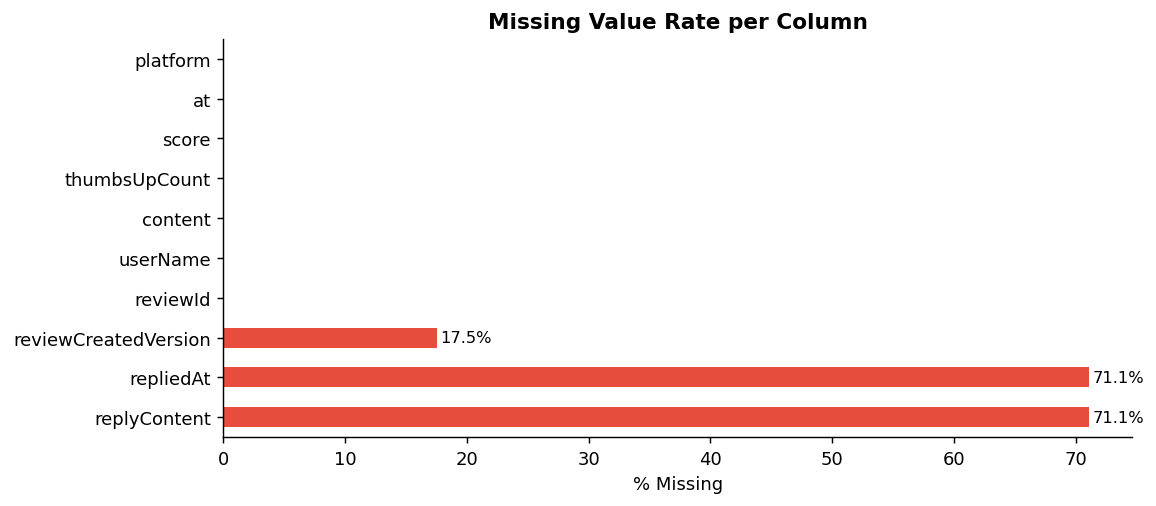

In [7]:
missing     = df_all.isnull().sum().rename("missing")
missing_pct = (df_all.isnull().mean() * 100).round(2).rename("pct_missing")
miss_df     = pd.concat([missing, missing_pct], axis=1).sort_values("pct_missing", ascending=False)
print(miss_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
miss_df["pct_missing"].plot(kind="barh", ax=ax, color="#E74C3C")
ax.set_xlabel("% Missing")
ax.set_title("Missing Value Rate per Column", fontweight="bold")
for i, val in enumerate(miss_df["pct_missing"]):
    if val > 0:
        ax.text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_missing_values.png", bbox_inches="tight")
plt.show()

> `replyContent` and `repliedAt` are both missing **71.07% (71,070 rows)**, consistent because they are only populated when the developer replies, meaning **only 1 in 3 reviews gets a response**. `reviewCreatedVersion` is missing **17.54%** because some users write reviews without updating to the latest version. The core analysis columns: `reviewId`, `content`, `score`, `at`, and `platform` are **100% complete with no missing values**, making the data ready for sentiment analysis and EDA without the need for imputation in the main columns.

## **8. Reviews per Platform**
Displays the distribution of reviews across the four platforms. Balanced data across platforms is fairer for comparing sentiment and ratings, eliminating bias due to volume.

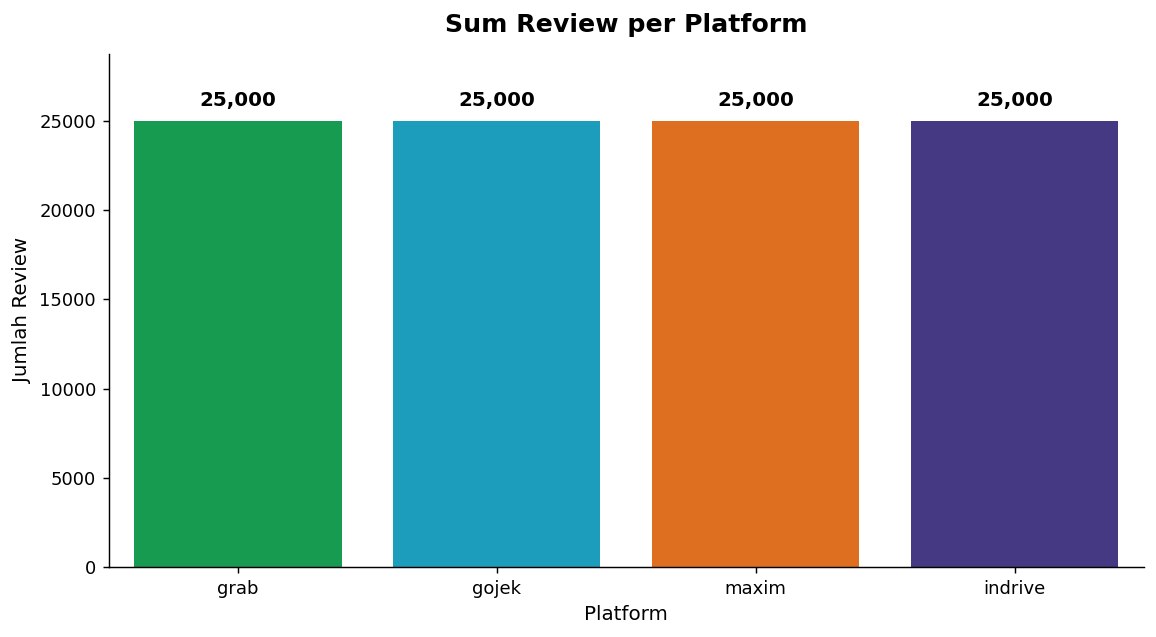

In [14]:
platform_counts = df_all["platform"].value_counts()

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=platform_counts.index,
    y=platform_counts.values,
    palette=[PALETTE.get(p, "#888888") for p in platform_counts.index]
)
plt.title("Sum Review per Platform", fontsize=14, fontweight="bold", pad=12)
plt.xlabel("Platform", fontsize=11)
plt.ylabel("Jumlah Review", fontsize=11)

for patch in ax.patches:
    ax.annotate(
        f"{int(patch.get_height()):,}",
        (patch.get_x() + patch.get_width() / 2., patch.get_height()),
        ha="center", va="bottom",
        xytext=(0, 6), textcoords="offset points",
        fontsize=11, fontweight="bold"
    )
plt.ylim(0, platform_counts.max() * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / "02_review_per_platform.png", bbox_inches="tight")
plt.show()

> All four platforms have a **perfectly balanced number of reviews, with exactly 25,000 each (100,000 total)**, meaning there is no volume bias in the comparison between platforms. This is ideal for competitive analysis because differences in sentiment percentage, ratings, and keyword frequency purely reflect differences in **service quality**, not simply differences in popularity or scraping scale.

## **9. Score Distribution per Platform**
Displays the distribution of star ratings (1–5) per platform in 4 subplots that share the Y-axis. The distribution pattern reveals whether ratings tend to be bimodal (many 1★ and 5★ ratings at once, extreme polarization) or normal.

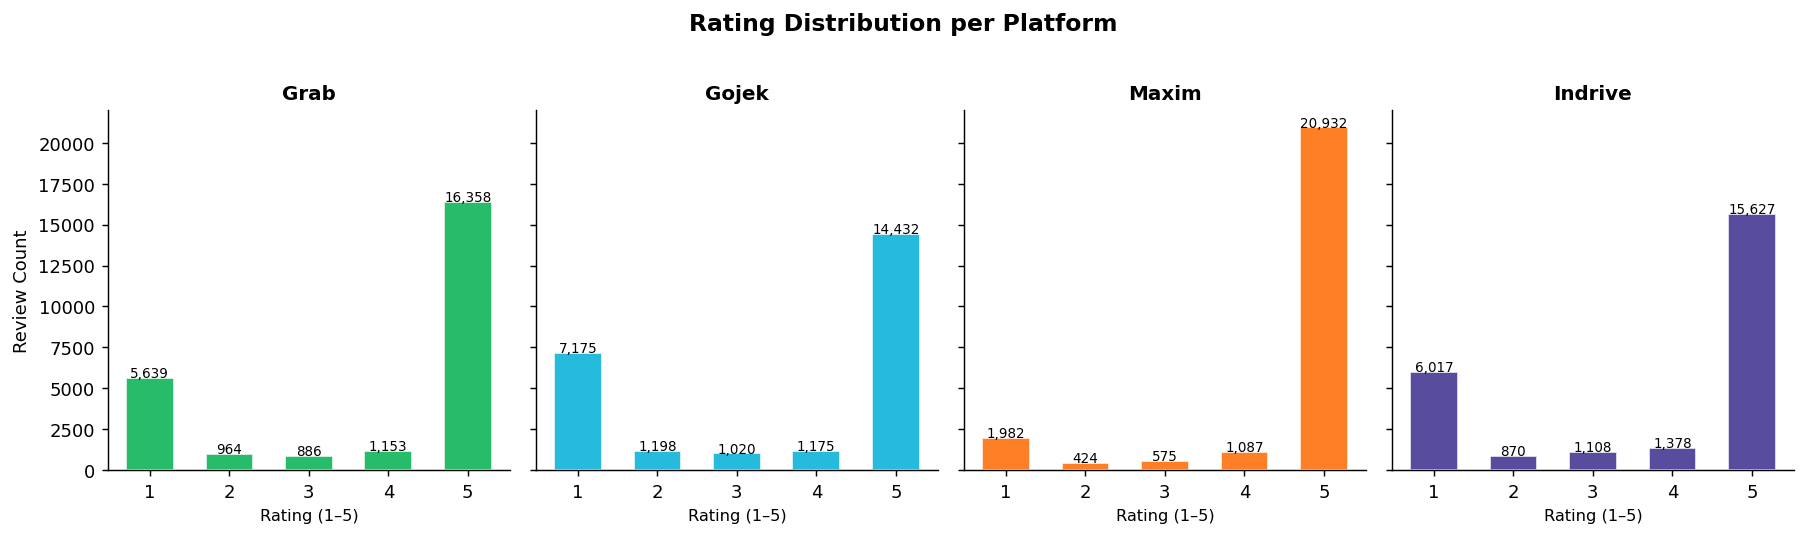

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

for ax, p in zip(axes, PLATFORMS):
    if p not in dfs:
        ax.set_visible(False)
        continue
    counts = dfs[p]["score"].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values,
                  color=PALETTE[p], alpha=0.85, edgecolor="white", width=0.6)
    ax.set_title(p.capitalize(), fontweight="bold", fontsize=11)
    ax.set_xlabel("Rating (1–5)", fontsize=9)
    ax.set_xticks([1, 2, 3, 4, 5])
    # Tambahkan label count di atas bar
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 50,
                    f"{int(h):,}", ha="center", fontsize=7.5)

fig.suptitle("Rating Distribution per Platform", fontsize=13, fontweight="bold", y=1.02)
axes[0].set_ylabel("Review Count")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_score_distribution.png", bbox_inches="tight")
plt.show()

> All four platforms show a **bimodal (U-shaped) distribution**, where ratings are heavily concentrated at the extremes, users are far more likely to leave a review when they are either very satisfied or very frustrated. **Maxim leads with the highest 5-star count (20,932)**, suggesting a strong loyal user base, while **Grab and Gojek show the largest 1-star spikes (5,639 and 7,175 respectively)**, indicating more vocal dissatisfaction compared to Maxim and InDrive. The near-absence of 2–4 star ratings across all platforms is typical of app store behavior and reinforces why median rating alone is insufficient; sentiment analysis on review text will be essential to uncover the nuance behind these polarized scores.

## **10. Statistical Summary**
Two layers of statistical summary: (a) `describe()` for a quick overview of the numerical distribution of all columns, and (b) a pre-compiled per-platform summary table with relevant metrics for competitive analysis.

In [10]:
# (a) Statistik deskriptif bawaan — semua kolom
print("=== df.describe(include='all') ===")
display(df_all.describe(include="all"))

=== df.describe(include='all') ===


,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,platform
count,100000,99999,100000,100000.000000,100000.00000,82459,100000,28930,28930,100000
unique,100000,94470,63776,NaN,NaN,695,NaN,14640,NaN,4
top,2b172bac-f26f-4d2d-8192-c6542de79b59,Pengguna Google,mantap,NaN,NaN,3.16.14,NaN,Halo Kak. Maaf ya buat enggak nyaman 🙇‍♀️\nApa...,NaN,grab
freq,1,275,3662,NaN,NaN,5055,NaN,1979,NaN,25000
mean,NaN,NaN,NaN,3.944090,0.83483,NaN,2026-01-25 14:17:59.173779968,NaN,2025-12-05 12:42:28.711372544,NaN
min,NaN,NaN,NaN,1.000000,0.00000,NaN,2025-04-22 01:28:07,NaN,2017-11-27 18:21:27,NaN
25%,NaN,NaN,NaN,3.000000,0.00000,NaN,2025-12-10 10:23:41,NaN,2025-10-06 20:36:07.500000,NaN
50%,NaN,NaN,NaN,5.000000,0.00000,NaN,2026-02-17 22:09:23.500000,NaN,2026-01-19 22:26:11,NaN
75%,NaN,NaN,NaN,5.000000,0.00000,NaN,2026-04-03 12:25:18.249999872,NaN,2026-03-23 14:12:23.500000,NaN
max,NaN,NaN,NaN,5.000000,1049.00000,NaN,2026-05-27 12:47:07,NaN,2026-05-28 08:06:46,NaN


In [11]:
# (b) Tabel ringkasan kompetitif per platform
stats = []
for p in PLATFORMS:
    if p not in dfs:
        continue
    d = dfs[p]
    stats.append({
        "Platform"         : p.capitalize(),
        "Total Reviews"    : len(d),
        "Avg Rating"       : round(d["score"].mean(), 2),
        "Median Rating"    : d["score"].median(),
        "% Rating 1-2 (Neg)": round((d["score"] <= 2).mean() * 100, 1),
        "% Rating 4-5 (Pos)": round((d["score"] >= 4).mean() * 100, 1),
        "Has Reply (%)"    : round(d["replyContent"].notna().mean() * 100, 1),
        "Date Range"       : f"{d['at'].min().date()} → {d['at'].max().date()}",
    })

summary = pd.DataFrame(stats)
display(summary)
summary.to_csv(CLEAN_DIR / "02_data_summary.csv", index=False)
print("\n✅ Summary saved → ../data/clean/02_data_summary.csv")

,Platform,Total Reviews,Avg Rating,Median Rating,% Rating 1-2 (Neg),% Rating 4-5 (Pos),Has Reply (%),Date Range
0,Grab,25000,3.87,5.0,26.4,70.0,38.3,2025-09-07 → 2026-05-27
1,Gojek,25000,3.58,5.0,33.5,62.4,32.0,2025-12-02 → 2026-05-27
2,Maxim,25000,4.54,5.0,9.6,88.1,0.7,2026-01-26 → 2026-05-27
3,Indrive,25000,3.79,5.0,27.5,68.0,44.7,2025-04-22 → 2026-05-27



✅ Summary saved → ../data/clean/02_data_summary.csv


> Based on the statistical summary, **Maxim** demonstrates the **highest customer satisfaction** with an impressive **average rating of 4.54** and **88.1% positive reviews**, while **Gojek** lags behind with the **lowest average rating of 3.58** and a higher share of **negative sentiment (33.5%)**. Despite having lower ratings, **Indrive and Grab** show **stronger operational engagement** by responding to **44.7% and 38.3%** of reviews respectively, whereas **Maxim** significantly underperforms in customer relations with a **negligible reply rate of just 0.7%**.

## **11. Review Volume Over Time**
Displays the monthly review volume trend per platform in a single line chart. A spike in volume in a given month could indicate an important event (a feature launch, a major promotion, or a viral service incident).

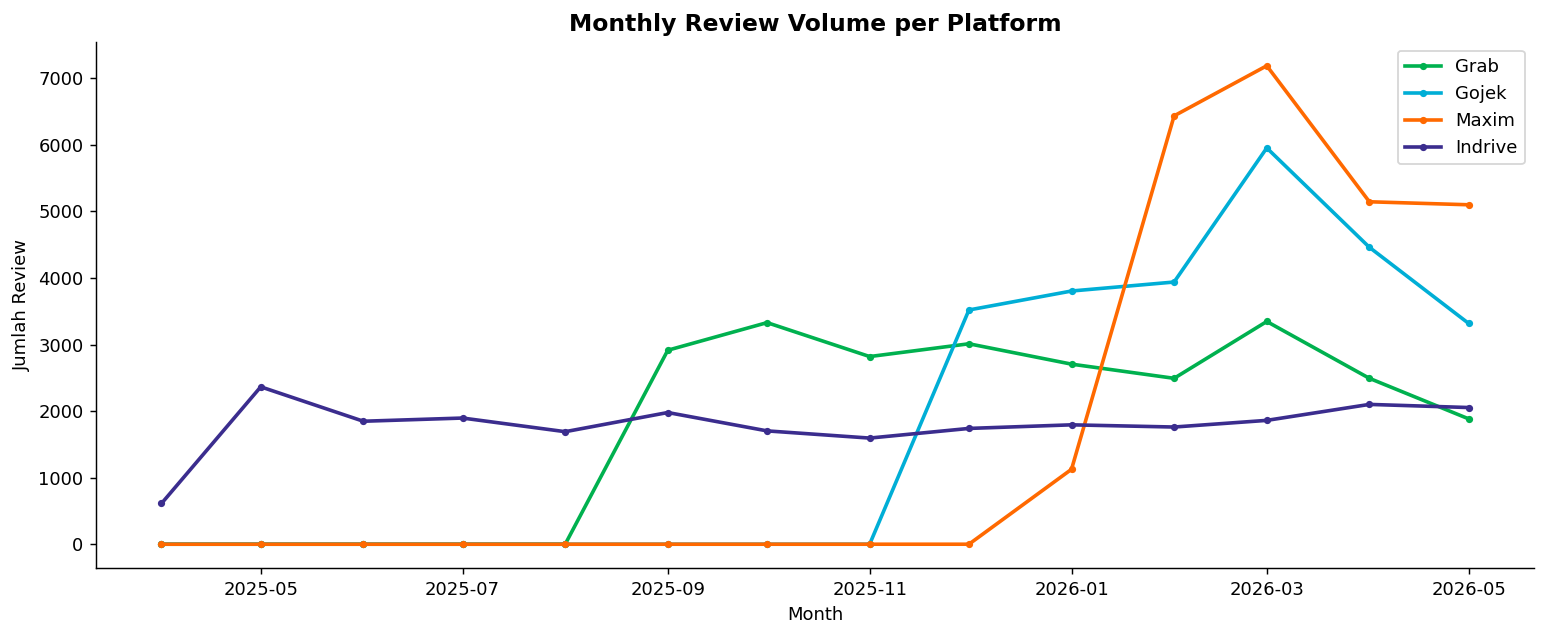

In [12]:
df_all["month"] = df_all["at"].dt.to_period("M")
monthly = df_all.groupby(["month", "platform"]).size().unstack(fill_value=0)
monthly.index = monthly.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 5))
for p in PLATFORMS:
    if p in monthly.columns:
        ax.plot(monthly.index, monthly[p],
                label=p.capitalize(), color=PALETTE[p],
                linewidth=2, marker="o", markersize=3)

ax.set_title("Monthly Review Volume per Platform", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Jumlah Review")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_monthly_volume.png", bbox_inches="tight")
plt.show()

> Based on the **"Monthly Review Volume per Platform"** trend chart, **Indrive** maintains the most **stable and consistent review volume** across the entire timeline starting from early 2025. In contrast, other platforms show staggered entry points and highly volatile growth, with **Grab's volume surging around September 2025**, followed by a **sharp influx for Gojek in late 2025**. The most dramatic shift occurs in early 2026, where **Maxim experiences an explosive growth spurt**, rapidly overtaking all competitors to reach a **peak of over 7,000 reviews around March 2026**, making it the most aggressively growing platform in user feedback volume despite its late start in the dataset.

## **12. Review Length Distribution**
Displays the distribution of review text length (in characters, clipped to a maximum of 1000) for each platform. Review length correlates with feedback depth, and longer reviews tend to be more informative for thematic and sentiment analysis.

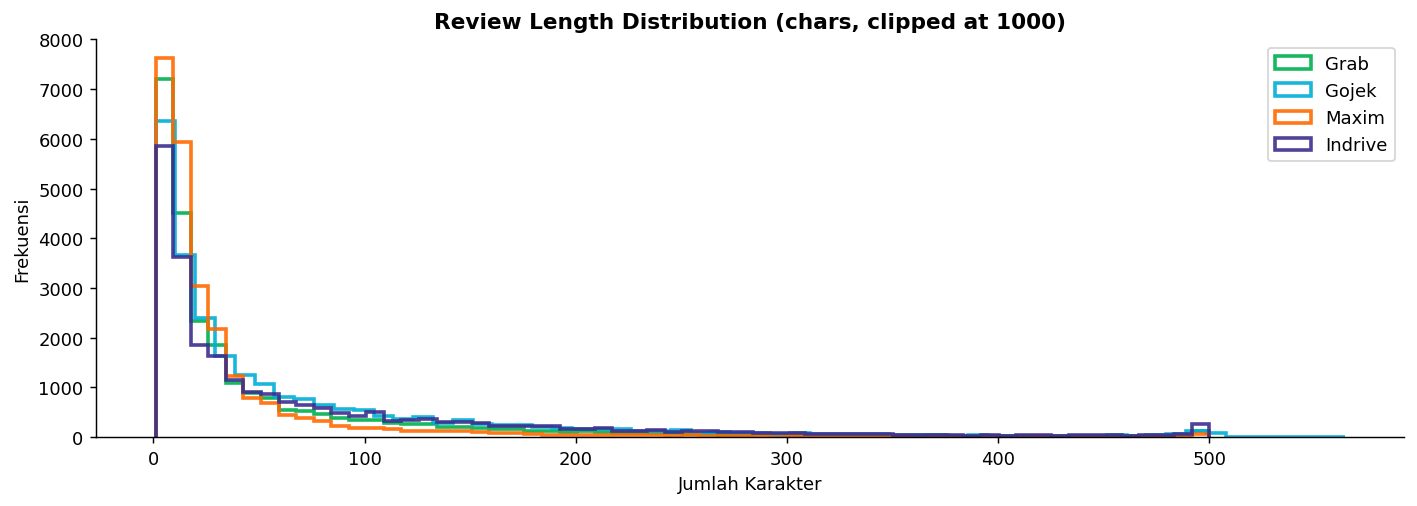


Review Length Statistics per Platform:


,Mean (chars),Median,75th pct,Max
platform,,,,
gojek,69.3,30.0,88.0,564.0
grab,54.6,20.0,60.2,500.0
indrive,76.6,31.0,101.0,500.0
maxim,34.9,15.0,34.0,500.0


In [15]:
df_all["review_len"] = df_all["content"].fillna("").astype(str).str.len()

fig, ax = plt.subplots(figsize=(11, 4))

for p in PLATFORMS:
    mask = df_all["platform"].str.lower() == p
    vals = df_all[mask]["review_len"].clip(0, 1000)

    if len(vals) == 0:
        print(f"⚠️ Data kosong untuk platform '{p}'")
        continue

    # Histogram outline (mirip KDE, tanpa dependensi scipy)
    ax.hist(vals, bins=60, histtype="step", linewidth=2,
            label=p.capitalize(), color=PALETTE.get(p, "grey"), alpha=0.9)

ax.set_title("Review Length Distribution (chars, clipped at 1000)", fontweight="bold")
ax.set_xlabel("Jumlah Karakter")
ax.set_ylabel("Frekuensi")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "02_review_length.png", bbox_inches="tight")
plt.show()

# Ringkasan statistik panjang review per platform
len_stats = df_all.groupby("platform")["review_len"].describe()[["mean","50%","75%","max"]].round(1)
len_stats.columns = ["Mean (chars)", "Median", "75th pct", "Max"]
print("\nReview Length Statistics per Platform:")
display(len_stats)

> Based on the **"Review Length Distribution"** chart and statistics, users across all platforms heavily favor **short, concise feedback**, as evidenced by the steep right-skewed distribution peaking well below 50 characters. Among the competitors, **Maxim** users leave the briefest commentary, recorded at a **median length of just 15 characters** and a **75th percentile of 34 characters**, which closely aligns with its high volume of simple, positive sentiments observed earlier. Conversely, **Indrive and Gojek** users tend to write more detailed feedback, leading with the highest **mean review lengths of 76.6 and 69.3 characters** respectively, indicating that their user bases are more inclined to articulate specific operational experiences or grievances.

## ✅ **Data Understanding — Summary**

| Metric | Value |
| --- | --- |
| Total reviews (combined) | **100,000 rows** *(from cell 3)*<br> |
| Date range | **2025-04-22 → 2026-05-27** *(from cell 10b)*<br> |
| Columns with missing > 50% | `replyContent` (71.07%), `repliedAt` (71.07%)
| Columns with light missingness | `reviewCreatedVersion` (17.54%), `userName` (1 row)
| Duplicate rows | **0**<br> 
| Platform with highest avg rating | **Maxim (4.54)** *(from cell 10b)*<br> 
| Platform with highest % developer reply | **Indrive (44.7%)** *(from cell 10b)*<br> 

**Key Observations:**

1. The data is perfectly **balanced** across platforms (exactly **25,000 rows each**) — making it fair for comparison.


2. Missing values in `replyContent`/`repliedAt` are expected and normal, as the majority of reviews do not receive a developer response.


3. The rating distribution tends to be bimodal — many users give a 1★ or 5★ rating, while 2–4★ ratings are rarely used.


4. Very short reviews dominate the dataset — a minimum threshold should be established during the data cleaning process in `03_data_cleaning.ipynb`.
